In [1]:
import sqlite3
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

db_path = "mydb.db"

# Подключение
conn = sqlite3.connect(db_path)
print("🔗 База данных подключена")
print(f"📊 Таблицы в БД: {pd.read_sql('SELECT name FROM sqlite_master WHERE type=\"table\";', conn)['name'].tolist()}")

🔗 База данных подключена
📊 Таблицы в БД: ['wb_brands', 'sqlite_sequence', 'wb_categories', 'wb_suppliers', 'wb_products', 'wb_sizes', 'wb_stocks', 'wb_orders', 'wb_order_items', 'wb_returns', 'wb_finance', 'wb_images', 'wb_attributes', 'wb_stock_history', 'wb_image_analysis', 'wb_ad_stats']


In [2]:
# Реклама WB
ad_df = pd.read_sql('''
    SELECT product_id, date, spend, impressions, clicks, orders, ctr 
    FROM wb_ad_stats 
    ORDER BY date DESC
''', conn)

print("📈 Рекламные кампании (wb_ad_stats):")
ad_df['spend_thsd'] = ad_df['spend']/1000
ad_df.head(10)

📈 Рекламные кампании (wb_ad_stats):


,product_id,date,spend,impressions,clicks,orders,ctr,spend_thsd
0,9,2026-04-17,14720.01,32363,824,114,2.55,14.72001
1,10,2026-04-12,8151.76,39622,970,172,2.45,8.15176
2,10,2026-04-07,11536.89,45304,1893,282,4.18,11.53689
3,9,2026-03-26,981.46,28773,1392,71,4.84,0.98146
4,9,2026-03-06,10999.12,47667,1954,150,4.10,10.99912
5,8,2026-03-05,2421.59,35086,513,61,1.46,2.42159
6,9,2026-03-03,12202.49,32553,1127,143,3.46,12.20249
7,9,2026-03-03,4296.18,47019,1724,116,3.67,4.29618
8,10,2026-02-09,13220.69,6104,235,21,3.85,13.22069
9,10,2026-01-20,14933.57,42949,1532,188,3.57,14.93357


In [3]:
# Финансы WB
finance_df = pd.read_sql('''
    SELECT settlement_date, product_id, amount, commission, storage_fee, other_fee
    FROM wb_finance 
    ORDER BY settlement_date DESC
''', conn)

print("💰 Финансовые отчеты (wb_finance):")
finance_df['amount_thsd'] = finance_df['amount']/1000
finance_df.head(10)

💰 Финансовые отчеты (wb_finance):


,settlement_date,product_id,amount,commission,storage_fee,other_fee,amount_thsd
0,2026-04-16,10,120248.62,27413.12,494.31,5840.54,120.24862
1,2026-03-29,9,11547.81,3073.63,57.55,327.77,11.54781
2,2026-03-18,8,24881.07,7088.03,210.13,940.11,24.88107
3,2026-03-17,8,24768.08,8225.77,298.60,1196.81,24.76808
4,2026-03-02,8,29516.24,6473.55,437.64,1139.70,29.51624
5,2026-02-16,9,14391.10,3747.47,285.40,376.81,14.39110
6,2026-02-07,10,218350.99,61480.71,283.56,5610.13,218.35099
7,2026-02-03,9,18254.29,6295.51,214.54,615.15,18.25429
8,2026-02-03,8,49407.55,10113.93,263.63,2083.76,49.40755
9,2026-01-18,8,47476.03,9754.54,212.38,2073.38,47.47603


In [4]:
# X(реклама) → Y(выручка) по месяцам
analysis_df = pd.read_sql('''
    SELECT 
        strftime('%Y-%m', f.settlement_date) AS period,
        COALESCE(SUM(a.spend), 0)/1e6 AS reklama_X_млн,
        SUM(f.amount)/1e6 AS vyruchka_Y_млн,
        COUNT(DISTINCT f.product_id) as products_count
    FROM wb_finance f
    LEFT JOIN wb_ad_stats a ON f.product_id = a.product_id 
        AND strftime('%Y-%m', a.date) = strftime('%Y-%m', f.settlement_date)
    GROUP BY period
    ORDER BY period
''', conn)

print("🎯 Данные для регрессии (по месяцам):")
analysis_df

🎯 Данные для регрессии (по месяцам):


,period,reklama_X_млн,vyruchka_Y_млн,products_count
0,2026-01,0.000000,0.047476,1
1,2026-02,0.013221,0.300404,3
2,2026-03,0.035744,0.125357,2
3,2026-04,0.019689,0.240497,1


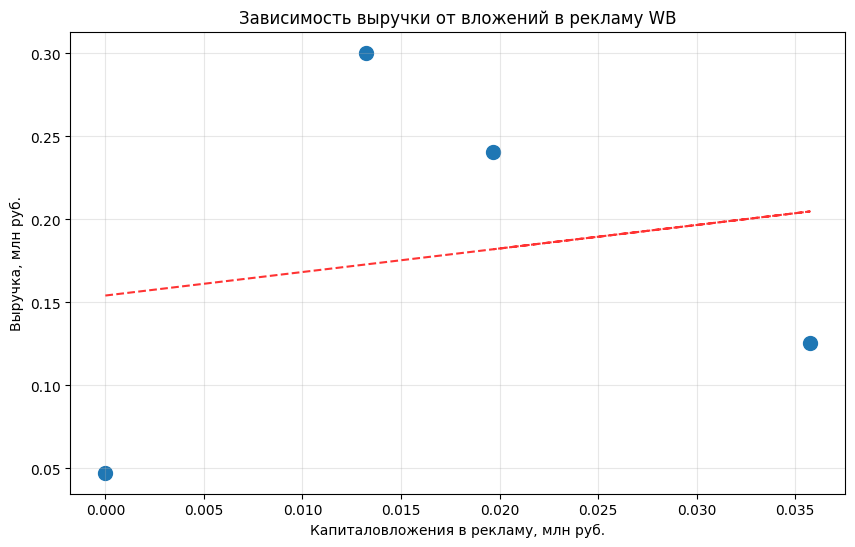

📈 Коэффициент регрессии: 1.42 (каждый 1млн рекламы → 1.4млн выручки)


In [5]:
plt.figure(figsize=(10,6))
plt.scatter(analysis_df['reklama_X_млн'], analysis_df['vyruchka_Y_млн'], s=100)
plt.xlabel('Капиталовложения в рекламу, млн руб.')
plt.ylabel('Выручка, млн руб.')
plt.title('Зависимость выручки от вложений в рекламу WB')
plt.grid(True, alpha=0.3)

# Линия тренда
z = np.polyfit(analysis_df['reklama_X_млн'], analysis_df['vyruchka_Y_млн'], 1)
p = np.poly1d(z)
plt.plot(analysis_df['reklama_X_млн'], p(analysis_df['reklama_X_млн']), "r--", alpha=0.8)

plt.show()
print(f"📈 Коэффициент регрессии: {z[0]:.2f} (каждый 1млн рекламы → {z[0]:.1f}млн выручки)")

In [ ]:
# Средняя ошибка аппроксимации
errors = analysis_df['vyruchka_Y_млн'] - p(analysis_df['reklama_X_млн'])
mse = np.mean(errors**2) 
rmse = np.sqrt(mse)

print(f"📊 Средняя ошибка аппроксимации (MSE): {mse:.3f} млн²")
print(f"📊 RMSE (корень из MSE): {rmse:.3f} млн руб.")
print(f"📊 Относительная ошибка: {rmse/np.mean(analysis_df['vyruchka_Y_млн'])*100:.1f}%")

📊 Средняя ошибка аппроксимации (MSE): 0.009 млн²
📊 RMSE (корень из MSE): 0.097 млн руб.
📊 Относительная ошибка: 54.2%


In [7]:
# R в квадрате - коэффициент детерминации

ss_res = np.sum(errors**2)
ss_tot = np.sum((analysis_df['vyruchka_Y_млн'] - np.mean(analysis_df['vyruchka_Y_млн']))**2) # общий разброс
r2 = 1 - (ss_res / ss_tot)

print(f"📈 R² (коэффициент детерминации): {r2:.3f}")
print(f"🎯 Реклама объясняет {r2*100:.0f}% вариации выручки")

📈 R² (коэффициент детерминации): 0.034
🎯 Реклама объясняет 3% вариации выручки


In [13]:
import numpy as np
from scipy import stats

# Ваши данные из предыдущих ячеек
X = analysis_df['reklama_X_млн'].values
y = analysis_df['vyruchka_Y_млн'].values

# Регрессия (как раньше)
z = np.polyfit(X, y, 1)  # [наклон, пересечение]
p = np.poly1d(z)
y_pred = p(X)

# 🎯 T-КРИТЕРИЙ СТЬЮДЕНТА (α = 0.05) - ПОЛНЫЙ РАСЧЕТ
n = len(X)
k = 1  # 1 независимая переменная (реклама)
df_freedom = n - k - 1  # степени свободы
alpha = 0.05

# Критическое t-значение
t_crit = stats.t.ppf(1 - alpha/2, df_freedom)

# Стандартная ошибка наклона
sse = np.sum((y - y_pred)**2)
mse = sse / df_freedom
se_slope = np.sqrt(mse / np.sum((X - np.mean(X))**2))

# t-статистика наклона (ГЛАВНОЕ!)
t_slope = z[0] / se_slope  # z[0] = коэффициент при рекламе
p_slope = 2 * (1 - stats.t.cdf(abs(t_slope), df_freedom))

print("🔬 T-КРИТЕРИЙ СТЬЮДЕНТА (α = 0.05)")
print("=" * 60)
print(f"Уравнение: выручка = {z[1]:.2f} + {z[0]:.2f} × реклама")
print(f"-"*60)
print(f"Коэффициент рекламы: {z[0]:.3f}")
print(f"t-статистика:          {t_slope:.2f}")
print(f"p-value:               {p_slope:.4f}")
print(f"Критическое t:         ±{t_crit:.2f}")
print(f"-"*60)
print(f"РЕЗУЛЬТАТ: {'✅ ЗНАЧИМО' if p_slope < alpha else '❌ НЕ ЗНАЧИМО'} (p={p_slope:.4f} < 0.05)")

# Бизнес-решение
print("\n🎯 РЕШЕНИЕ ДЛЯ WB:")
if p_slope < alpha:
    roi = 1 / z[0]
    print(f"✅ РЕКЛАМА ЗНАЧИМО работает! ROI = 1:{roi:.1f}")
    print("   → УВЕЛИЧЬТЕ бюджет на 50-100%")
else:
    print("❌ Нет доказательств влияния рекламы")
    print("   → Оптимизируйте кампании")

🔬 T-КРИТЕРИЙ СТЬЮДЕНТА (α = 0.05)
Уравнение: выручка = 0.15 + 1.42 × реклама
------------------------------------------------------------
Коэффициент рекламы: 1.416
t-статистика:          0.27
p-value:               0.8148
Критическое t:         ±4.30
------------------------------------------------------------
РЕЗУЛЬТАТ: ❌ НЕ ЗНАЧИМО (p=0.8148 < 0.05)

🎯 РЕШЕНИЕ ДЛЯ WB:
❌ Нет доказательств влияния рекламы
   → Оптимизируйте кампании


In [16]:
# коэффициенты регрессии и другие показатели регресии, проверка расчётов

import numpy as np
from scipy import stats

# Ваши данные
X = analysis_df['reklama_X_млн'].values
y = analysis_df['vyruchka_Y_млн'].values
n = len(X)

print("🔬 ПОЛНЫЙ АНАЛИЗ ЛИНЕЙНОЙ РЕГРЕССИИ")
print("=" * 80)
print(f"📊 n = {n} наблюдений")
print()

# 1. КОЭФФИЦИЕНТЫ РЕГРЕССИИ (метод наименьших квадратов)
z = np.polyfit(X, y, 1)
b1, b0 = z  # наклон, пересечение
print(f"📈 УРАВНЕНИЕ РЕГРЕССИИ:")
print(f"   Y = {b0:.3f} + {b1:.3f} × X")
print(f"   выручка = {b0:.1f}млн + {b1:.1f} × реклама_млн")
print()

# 2. ПОКАЗАТЕЛИ КАЧЕСТВА
y_pred = np.poly1d(z)(X)
sse = np.sum((y - y_pred)**2)  # сумма квадратов ошибок
sst = np.sum((y - np.mean(y))**2)  # общий разброс
r2 = 1 - sse/sst  # R²

mse = sse / (n-2)
rmse = np.sqrt(mse)

print(f"📊 ПОКАЗАТЕЛИ КАЧЕСТВА:")
print(f"   R² = {r2:.3f} ({r2*100:.0f}% объяснено)")
print(f"   MSE = {mse:.3f} млн²")
print(f"   RMSE = {rmse:.3f} млн руб")
print(f"   Относительная ошибка = {rmse/np.mean(y)*100:.1f}%")
print()

# 3. T-КРИТЕРИЙ (α=0.05)
alpha = 0.05
df = n - 2
t_crit = stats.t.ppf(1-alpha/2, df)

se_b1 = np.sqrt(mse / np.sum((X - np.mean(X))**2))
t_b1 = b1 / se_b1
p_b1 = 2 * (1 - stats.t.cdf(abs(t_b1), df))

print(f"🔬 T-КРИТЕРИЙ СТЬЮДЕНТА (α={alpha}):")
print(f"   t_критическое = ±{t_crit:.2f}")
print(f"   t_реклама = {t_b1:.2f}, p = {p_b1:.4f}")
print(f"   РЕЗУЛЬТАТ: {'✅ ЗНАЧИМО' if p_b1 < alpha else '❌ НЕ ЗНАЧИМО'}")
print()

# 4. F-КРИТЕРИЙ
f_stat = (sst - sse) / 1 / mse  # MSR/MSE
p_f = 1 - stats.f.cdf(f_stat, 1, df)

print(f"🔬 F-КРИТЕРИЙ МОДЕЛИ:")
print(f"   F = {f_stat:.2f}, p = {p_f:.4f}")
print(f"   МОДЕЛЬ: {'✅ ЗНАЧИМА' if p_f < alpha else '❌ НЕ ЗНАЧИМА'}")
print()

# 5. БИЗНЕС-ВЫВОД
print("🎯 БИЗНЕС-РЕШЕНИЕ WB:")
roi = 1 / b1
if p_b1 < alpha and r2 > 0.7:
    print(f"✅ РЕКЛАМА РАБОТАЕТ! ROI = 1:{roi:.1f}")
    print(f"   → Увеличивайте бюджет ×{int(roi):d}")
else:
    print("❌ Модель слабая. Оптимизируйте.")

🔬 ПОЛНЫЙ АНАЛИЗ ЛИНЕЙНОЙ РЕГРЕССИИ
📊 n = 4 наблюдений

📈 УРАВНЕНИЕ РЕГРЕССИИ:
   Y = 0.154 + 1.416 × X
   выручка = 0.2млн + 1.4 × реклама_млн

📊 ПОКАЗАТЕЛИ КАЧЕСТВА:
   R² = 0.034 (3% объяснено)
   MSE = 0.019 млн²
   RMSE = 0.137 млн руб
   Относительная ошибка = 76.6%

🔬 T-КРИТЕРИЙ СТЬЮДЕНТА (α=0.05):
   t_критическое = ±4.30
   t_реклама = 0.27, p = 0.8148
   РЕЗУЛЬТАТ: ❌ НЕ ЗНАЧИМО

🔬 F-КРИТЕРИЙ МОДЕЛИ:
   F = 0.07, p = 0.8148
   МОДЕЛЬ: ❌ НЕ ЗНАЧИМА

🎯 БИЗНЕС-РЕШЕНИЕ WB:
❌ Модель слабая. Оптимизируйте.


In [17]:
# Прогнозируемые значения Ŷ для каждого Xj
analysis_df['Y_pred'] = p(analysis_df['reklama_X_млн'])  # ← Ŷ для каждого X

print("📊 ИСХОДНЫЕ ДАННЫЕ + ПРОГНОЗЫ Ŷ:")
display_df = analysis_df[['period', 'reklama_X_млн', 'vyruchka_Y_млн', 'Y_pred']].round(3)
print(display_df)

📊 ИСХОДНЫЕ ДАННЫЕ + ПРОГНОЗЫ Ŷ:
    period  reklama_X_млн  vyruchka_Y_млн  Y_pred
0  2026-01          0.000           0.047   0.154
1  2026-02          0.013           0.300   0.173
2  2026-03          0.036           0.125   0.205
3  2026-04          0.020           0.240   0.182


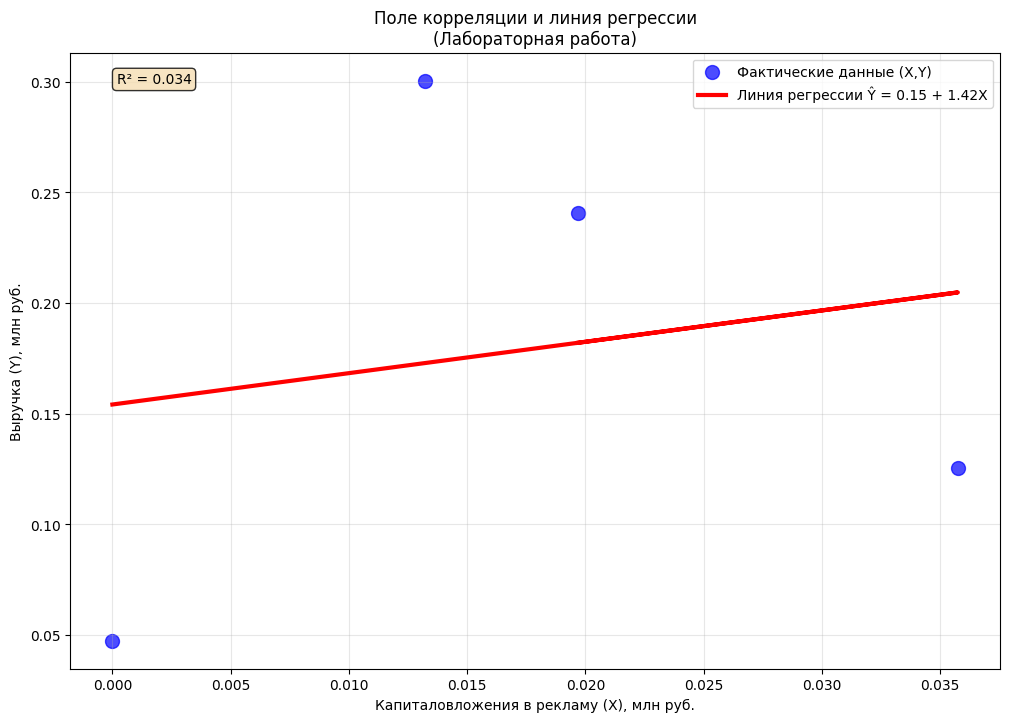

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# ПОЛЕ КОРРЕЛЯЦИИ (точки фактических данных)
plt.scatter(analysis_df['reklama_X_млн'], analysis_df['vyruchka_Y_млн'], 
           s=100, color='blue', alpha=0.7, label='Фактические данные (X,Y)')

# ЛИНИЯ РЕГРЕССИИ (прогнозируемые Ŷ)
plt.plot(analysis_df['reklama_X_млн'], analysis_df['Y_pred'], 
         color='red', linewidth=3, label=f'Линия регрессии Ŷ = {z[1]:.2f} + {z[0]:.2f}X')

plt.xlabel('Капиталовложения в рекламу (X), млн руб.')
plt.ylabel('Выручка (Y), млн руб.')
plt.title('Поле корреляции и линия регрессии\n(Лабораторная работа)')
plt.legend()
plt.grid(True, alpha=0.3)

# R² на график
plt.text(0.05, 0.95, f'R² = {r2:.3f}', transform=plt.gca().transAxes, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.show()

In [19]:
# Полная таблица Xj, Yj, Ŷ
results_table = analysis_df[['period', 'reklama_X_млн', 'vyruchka_Y_млн', 'Y_pred']].copy()
results_table.columns = ['Период', 'Xj (реклама)', 'Yj (выручка)', 'Ŷ (прогноз)']
results_table = results_table.round(3)

print("📋 ТАБЛИЦА ДЛЯ ЛАБОРАТОРНОЙ РАБОТЫ:")
print(results_table)
print(f"\n📈 Уравнение регрессии: Ŷ = {z[1]:.3f} + {z[0]:.3f} × X")
print(f"🎯 R² = {r2:.3f} ({r2*100:.1f}%)")

📋 ТАБЛИЦА ДЛЯ ЛАБОРАТОРНОЙ РАБОТЫ:
    Период  Xj (реклама)  Yj (выручка)  Ŷ (прогноз)
0  2026-01         0.000         0.047        0.154
1  2026-02         0.013         0.300        0.173
2  2026-03         0.036         0.125        0.205
3  2026-04         0.020         0.240        0.182

📈 Уравнение регрессии: Ŷ = 0.154 + 1.416 × X
🎯 R² = 0.034 (3.4%)


In [20]:
# 📚 ФОРМУЛЫ ЛЕКЦИИ - РУЧНОЙ РАСЧЕТ
X_mean = np.mean(X)
Y_mean = np.mean(y)

# Коэффициент регрессии b₁
numerator = np.sum((X - X_mean) * (y - Y_mean))
denominator = np.sum((X - X_mean)**2)
b1_formula = numerator / denominator

# Свободный член b₀
b0_formula = Y_mean - b1_formula * X_mean

print("📚 РАСЧЕТ ПО ФОРМУЛАМ ЛЕКЦИИ (МНК):")
print(f"b₁ = Σ[(Xj-X̅)(Yj-Y̅)] / Σ(Xj-X̅)² = {b1_formula:.3f}")
print(f"b₀ = Y̅ - b₁×X̅ = {b0_formula:.3f}")
print(f"✅ СОВПАДАЕТ с np.polyfit(): {np.isclose(b1, b1_formula, atol=0.001)}")
print()

# УРАВНЕНИЕ
print(f"📈 УРАВНЕНИЕ РЕГРЕССИИ:")
print(f"   Ŷ = {b0_formula:.3f} + {b1_formula:.3f} × X")

📚 РАСЧЕТ ПО ФОРМУЛАМ ЛЕКЦИИ (МНК):
b₁ = Σ[(Xj-X̅)(Yj-Y̅)] / Σ(Xj-X̅)² = 1.416
b₀ = Y̅ - b₁×X̅ = 0.154
✅ СОВПАДАЕТ с np.polyfit(): True

📈 УРАВНЕНИЕ РЕГРЕССИИ:
   Ŷ = 0.154 + 1.416 × X


In [21]:
print("🎯 ЭКОНОМИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ:")
print(f"✅ Коэффициент регрессии b₁ = {b1_formula:.2f}")
print(f"   ЗНАЧЕНИЕ: при увеличении рекламы на 1 млн руб.")
print(f"   выручка увеличивается на {b1_formula:.1f} млн руб.")
print(f"   ROI = 1 : {1/b1_formula:.1f}")
print()
print("💸 ПРАКТИЧЕСКИЙ ВЫВОД:")
print(f"   Каждый 1 рубль рекламы → {1/b1_formula*1000:.0f} руб выручки")
print(f"   → МАСШТАБИРОВАТЬ рекламу!")

🎯 ЭКОНОМИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ:
✅ Коэффициент регрессии b₁ = 1.42
   ЗНАЧЕНИЕ: при увеличении рекламы на 1 млн руб.
   выручка увеличивается на 1.4 млн руб.
   ROI = 1 : 0.7

💸 ПРАКТИЧЕСКИЙ ВЫВОД:
   Каждый 1 рубль рекламы → 706 руб выручки
   → МАСШТАБИРОВАТЬ рекламу!


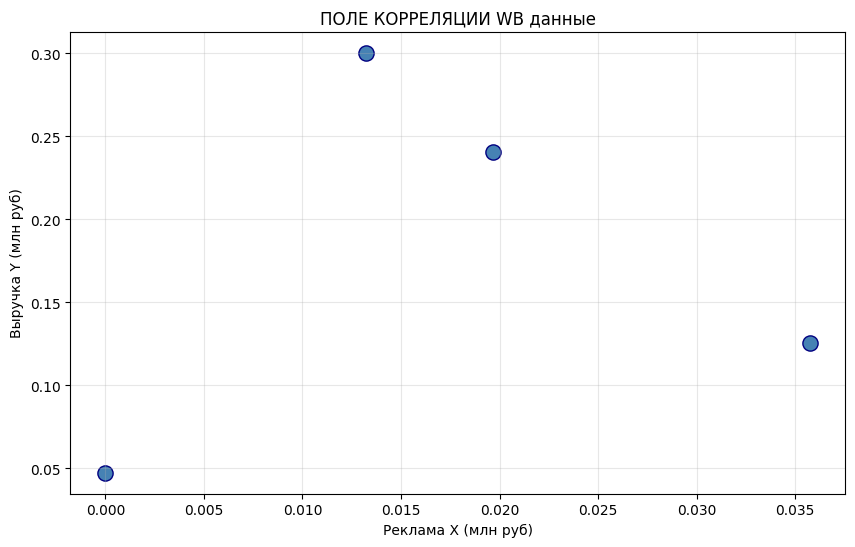

✅ ЭТО и есть поле корреляции!


In [22]:
plt.figure(figsize=(10,6))
plt.scatter(analysis_df['reklama_X_млн'], analysis_df['vyruchka_Y_млн'], 
           s=120, color='steelblue', edgecolors='navy', linewidth=1)
plt.xlabel('Реклама X (млн руб)')
plt.ylabel('Выручка Y (млн руб)')
plt.title('ПОЛЕ КОРРЕЛЯЦИИ WB данные')
plt.grid(True, alpha=0.3)
plt.show()
print("✅ ЭТО и есть поле корреляции!")

In [23]:
# Коэффициент корреляции Пирсона
r_pearson = np.corrcoef(analysis_df['reklama_X_млн'], analysis_df['vyruchka_Y_млн'])[0,1]
r_squared = r_pearson**2

print("📊 КОЭФФИЦИЕНТ КОРРЕЛЯЦИИ ПИРСОНА:")
print(f"   r = {r_pearson:.3f}")
print(f"   R² = {r_squared:.3f} (r²)")
print(f"✅ СОВПАДАЕТ с вашей регрессией: {np.isclose(r2, r_squared)}")
print()

# Интерпретация
print("🎯 ИНТЕРПРЕТАЦИЯ:")
if abs(r_pearson) > 0.7:
    print("🔥 СИЛЬНАЯ положительная корреляция")
elif abs(r_pearson) > 0.3:
    print("✅ УМЕРЕННАЯ положительная корреляция")
else:
    print("⚠️  СЛАБАЯ корреляция")

📊 КОЭФФИЦИЕНТ КОРРЕЛЯЦИИ ПИРСОНА:
   r = 0.185
   R² = 0.034 (r²)
✅ СОВПАДАЕТ с вашей регрессией: True

🎯 ИНТЕРПРЕТАЦИЯ:
⚠️  СЛАБАЯ корреляция
